In [1]:
import kwant
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eig
from scipy.optimize import fmin

In [2]:
#function
#ABS
def gr_L(T_l, A_l, check_tol=1e-6):

    N = T_l.shape[0]
    I = np.eye(N)
    Tmat = np.block([
        [np.linalg.inv(T_l) @ A_l, -np.linalg.inv(T_l) @ T_l.conj().T],
        [I, np.zeros((N, N))]
    ])

    eigvals, eigvecs = eig(Tmat)


    idx = np.argsort(np.abs(eigvals))
    eigvals = eigvals[idx]
    eigvecs = eigvecs[:, idx]

    lambdas = eigvals[:N]
    vecs = eigvecs[:, :N]

    S1 = vecs[:N, :] 
    S2 = vecs[N:, :]  

    gL = np.linalg.inv(A_l - T_l @ S1 @ np.linalg.inv(S2))
    check = (A_l - T_l @ gL @ T_l.conj().T) @ gL - I
    max_err = np.max(np.abs(check))

    #if max_err > check_tol:
    #    mag = np.abs(eigvals)
    #    print("Sorted |eigvals|:", np.sort(mag))
    #    raise RuntimeError(
    #        fr"Self-consistency violated: max |Δ| = {max_err}"
    #    )
    return gL

def zinengr_L(T_LD_wei ,gr_L_wei):
    return T_LD_wei.conj().T @ gr_L_wei @ T_LD_wei

def Gr_DD_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=1e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD_kuaisanjiao(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, E, eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])

    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):
        G_DD_r[i][i] = g_ii[i]

    for i in range(N-1):
        G_DD_r[i][i+1] = g_ii[i] @ c_R[i+1]


    for i in range(N-1):
        G_DD_r[i+1][i] = g_ii[i+1] @ c_L[i]

    G_DD_r = np.block(G_DD_r)
    A_DD = np.block(A_DD)
    return G_DD_r , A_DD , Sigma_R , Sigma_L 

def Gr_DD(H_q,H_l,H_r,  T_12,T_LD,T_l,T_RD,T_r,  N,E,eta=3e-6):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(E + 1j*eta)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (E + 1j*eta)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T
    A_DD = np.block(A_DD)
    G_DD_r = np.linalg.inv(A_DD)
    return G_DD_r , A_DD ,Sigma_R ,Sigma_L 
    
def bufeng(G_DD_r):
    d = H_q.shape[0]
    yigeshu=np.trace(G_DD_r[q*d:(q+1)*d, (q)*d:(q+1)*d])
    return -np.imag(yigeshu)/np.pi

def find_peaks_fmin(A_of_E, E_min, E_max, N_guess=11, xtol=1e-6, ftol=1e-6, round_digits=6):

    E_guesses = np.linspace(E_min, E_max, N_guess)
    peak_list = []

    for E0 in E_guesses:
        r = fmin(lambda E: -A_of_E(E), E0, disp=False, xtol=xtol, ftol=ftol)
        peak_list.append(r[0])

    peak_list = np.unique(np.round(peak_list, round_digits))
    return peak_list


#current1
def Gr_DD_MS_quan(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    g_ii = [np.zeros((d, d), dtype=complex) for _ in range(N)]

    d_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_R = [np.zeros((d, d), dtype=complex) for _ in range(N)]#第一个是0
    for i in range(N-1,-1,-1):
        if i==N-1:
            d_R[i]=A_DD[i][i]
        else:
            c_R[i+1]=-1*A_DD[i][i+1] @ np.linalg.inv(d_R[i+1])
            d_R[i]=A_DD[i][i]+c_R[i+1] @ A_DD[i+1][i]

    d_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]
    c_L = [np.zeros((d, d), dtype=complex) for _ in range(N)]#最后一个是0

    for i in range(N):
        if i==0:
            d_L[i]=A_DD[i][i]
        else:
            c_L[i-1]=-1*A_DD[i][i-1] @ np.linalg.inv(d_L[i-1])
            d_L[i]=A_DD[i][i]+ c_L[i-1] @ A_DD[i-1][i]

        g_ii[i]=np.linalg.inv(-A_DD[i][i]+d_L[i]+d_R[i])


    G_DD_r = [[Z.copy() for _ in range(N)] for _ in range(N)]
    for i in range(N):
        for j in range(N):

            if i == j:
                G_DD_r[i][j] = g_ii[i]

            elif i > j:
                prod = np.eye(d, dtype=complex)
                for k in range(i-1, j-1, -1):
                    prod = prod @ c_L[k]
                G_DD_r[i][j] = g_ii[i] @ prod


            else:  
                prod = np.eye(d, dtype=complex)
                for k in range(i+1, j+1):
                    prod = prod @ c_R[k]
                G_DD_r[i][j] = g_ii[i] @ prod


    G_DD_wn = np.block(G_DD_r)
    A_DD_wn = np.block(A_DD)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    return G_DD_wn , A_DD_wn , Sigma_R , Sigma_L 

def Gr_DD_MS_gaiyixia(H_q, H_l, H_r, T_12, T_LD, T_l, T_RD, T_r, N, wn):
    d = H_q.shape[0]
    I = np.eye(d, dtype=complex)
    Z = np.zeros((d, d), dtype=complex)

    EI_gai = np.block([
        [(1j*wn)*s0, np.zeros((2,2))],
        [np.zeros((2,2)), (1j*wn)*s0]
    ])

    A_l = EI_gai - H_l
    gcl = gr_L(T_l, A_l)
    Sigma_L = zinengr_L(T_LD, gcl)

    A_r = EI_gai - H_r
    gcr = gr_L(T_r, A_r)
    Sigma_R = zinengr_L(T_RD, gcr)


    A_DD = [[Z.copy() for _ in range(N)] for _ in range(N)]

    for i in range(N):

        if i == 0:
            A_DD[i][i] = EI_gai - H_q - Sigma_L
        elif i == N-1:
            A_DD[i][i] = EI_gai - H_q - Sigma_R
        else:
            A_DD[i][i] = EI_gai - H_q

        if i < N-1:
            A_DD[i][i+1] = -T_12

        if i > 0:
            A_DD[i][i-1] = -T_12.conj().T

    A_DD_wn = np.block(A_DD)
    G_DD_wn = np.linalg.inv(A_DD_wn)
    f_E= 1/(1+np.exp((1j*wn - mu)/KBT))
    G_DD_wn_xiao=f_E*(G_DD_wn.conj()-G_DD_wn)
    return G_DD_wn_xiao , A_DD_wn , Sigma_R , Sigma_L 

def J_wn(G_DD_wn, T_12, q):
    d = T_12.shape[0]

    G_q_q1 = G_DD_wn[q*d:(q+1)*d, (q+1)*d:(q+2)*d]
    G_q1_q = G_DD_wn[(q+1)*d:(q+2)*d, q*d:(q+1)*d]

    Jmat = T_12.conj().T @ G_q1_q - G_q_q1 @ T_12
    d_e = d //2
    return np.trace(Jmat[:d_e, :d_e])*(-1j)*KBT
    #return np.trace(Jmat)*(-1j)*KBT

def matsubara_list(shumu):
    n_max =  shumu
    n_vals = np.arange(-n_max, n_max+1 )
    wn = (2 * n_vals + 1) * np.pi * KBT

    return wn.tolist()

def J_matsubara_sum(shumu,H_q, H_l, H_r,T_12, T_LD, T_l, T_RD, T_r,N, q):
    wn_list = matsubara_list(shumu)
    J_sum = 0.0 
    for wn in wn_list:
        G_DD_wn, _, _, _ = Gr_DD_MS_gaiyixia(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, wn
        )

        J_sum += np.real(J_wn(G_DD_wn, T_12, q))
    return (J_sum)


#current2
def JoseCurrent(H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD):
    H_L = H_l
    H_R = H_r
    H_D = H_q

    T_L = T_l
    T_R = T_r
    T_D = T_12
    T_DR = T_RD
    T_DL = T_LD.conj().T

    lx = Lx // 2

    # temperature
   

    kBT = KBT
    mmax = shumu

    current = 0
    N = H_D.shape[0]

    for m in range(-(mmax + 1), mmax + 1):

        ef = 1j * (2*m + 1) * np.pi * kBT
        #EE = (ef + 1j*1e-6) * np.eye(N)
        EE = (ef ) * np.eye(N)
        # ================= Right Lead =================
        inv_TR = np.linalg.inv(T_R)

        TT_R = np.block([
            [inv_TR @ (EE - H_R), -inv_TR @ T_R.conj().T],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_R)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_R = np.linalg.inv(
            EE - H_R - T_R @ S1 @ np.linalg.inv(S2)
        )

        SigmaR = T_DR @ g_R @ T_DR.conj().T

        # ================= Left Lead =================
        inv_TR_dag = np.linalg.inv(T_R.conj().T)

        TT_L = np.block([
            [inv_TR_dag @ (EE - H_L), -inv_TR_dag @ T_R],
            [np.eye(N), np.zeros((N, N))]
        ])

        eigval, eigvec = np.linalg.eig(TT_L)
        idx = np.argsort(np.abs(eigval))

        v = eigvec[:, idx]
        S1 = v[:N, :N]
        S2 = v[N:2*N, :N]

        g_L = np.linalg.inv(
            EE - H_L - T_R.conj().T @ S1 @ np.linalg.inv(S2)
        )

        SigmaL = T_DL @ g_L @ T_DL.conj().T

        # ================= Device Green Function =================
        G11 = np.linalg.inv(EE - H_D - SigmaL)
        GNN = np.linalg.inv(EE - H_D - SigmaR)

        Gii = G11
        for _ in range(2, lx):
            Gii = np.linalg.inv(
                EE - H_D - T_D.conj().T @ Gii @ T_D
            )

        Gkk = GNN
        for _ in range(Lx-1, lx, -1):
            Gkk = np.linalg.inv(
                EE - H_D - T_D @ Gkk @ T_D.conj().T
            )

        Sigma_i = T_D.conj().T @ Gii @ T_D
        Sigma_k = T_D @ Gkk @ T_D.conj().T

        Gll = np.linalg.inv(
            EE - H_D - Sigma_i - Sigma_k
        )

        # ================= Current Operator =================
        GFO_SN = Gll @ T_D.conj().T @ Gii
        GFOD_SN = Gii @ T_D @ Gll

        SIGM0 = np.array([[1,0,0,0],[0,1,0,0],[0,0,-1,0],
                          [0,0,0,-1]])

        current_matrix = SIGM0 @ (
            T_D @ (1j * GFO_SN)
            - T_D.conj().T @ (1j * GFOD_SN)
        )

        dc = np.real(np.trace(current_matrix))

        current += kBT / Delta * dc

    return current


In [ ]:
#参数1
dela = 0.1875
t = 38*dela
af =1
a = 1
mu = 8*dela


hc=1.2#100
h =hc * np.sqrt(mu**2 + dela**2)
hz=1*dela
chaodaojiao = 0
#saimanjiao=np.pi/6
saimanjiao = np.pi*0


U = 1.9*dela

mz = 0*dela#0.098614 #【0.422270(mc=0,af=0，最小0)】,【0.098614(mc=1,af=1,最大1)】
mc=1
m =  h*mc
zhongjian_saimanjiao=np.pi*0
af6666=1

T_Tc=0.5
Delta = dela * np.tanh(1.74 * np.sqrt(1 / T_Tc - 1))

N=10
Lx=N
q=3
shumu=int(np.floor(50*Delta/ T_Tc))
KBT=2 * dela * T_Tc / 3.5

#矩阵信息
sx = np.array([[0, 1], [1, 0]], complex)
sy = np.array([[0, -1j], [1j, 0]], complex)
sz = np.array([[1, 0], [0, -1]], complex)
s0 = np.array([[1, 0], [0, 1]], complex)

#左边矩阵信息
HL_block=-(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy +hz*sz
Delta_L=Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
H_L_onsite=np.block([
        [ HL_block,        Delta_L        ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])
H_L_right_to_left_hop_block=-1*(t*s0+1j*af*sz/a)
H_L_right_to_left_hop=np.block([
        [ H_L_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_L_right_to_left_hop_block.conj() ]
    ])

#中间矩阵信息
H_center_to_L=np.block([
        [ -1*t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])


H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])


H_center_right_to_left_hop_block=-1*(t*s0+1j*af*sz*af6666/a)
H_center_right_to_left_hop=np.block([
        [ H_center_right_to_left_hop_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_right_to_left_hop_block.conj() ]
    ])


H_R_to_center=np.block([
        [ -t*s0,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , t*s0 ]
    ])

#右边矩阵信息
HR_block=-(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy +hz*sz
Delta_R=Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
H_R_onsite=np.block([
        [ HR_block,        Delta_R        ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
H_R_right_to_left_hop_block=-1*(t*s0+1j*af/a*sz)
H_R_right_to_left_hop=np.block([
        [ H_R_right_to_left_hop_block,        np.zeros((2,2))],
        [ np.zeros((2,2)), -H_R_right_to_left_hop_block.conj() ]
    ])


#输入矩阵
H_q=H_center
T_12= H_center_right_to_left_hop.conj().T

H_l= H_L_onsite
T_l= H_L_right_to_left_hop

H_r= H_R_onsite
T_r=H_R_right_to_left_hop.conj().T

T_LD=H_center_to_L
T_RD= H_R_to_center

shumu*2*np.pi*KBT/Delta

32.458481097839275

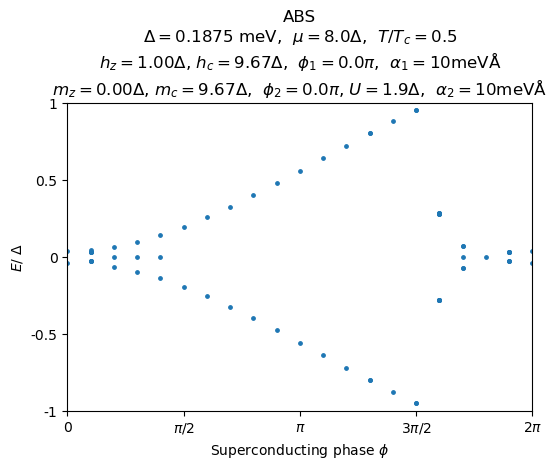

In [44]:
phi_set = np.linspace(0, 2*np.pi, 21)     # 超导相位
sdsd=1
E_min, E_max = -Delta *sdsd, Delta *sdsd

phi_list = []
E_peak_list = []

for phi in phi_set:
    chaodaojiao = phi

    Delta_L = Delta * np.exp(-1j*chaodaojiao/2) * 1j * sy
    H_L_onsite = np.block([
        [ HL_block,          Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*chaodaojiao/2) * 1j * sy
    H_R_onsite = np.block([
        [ HR_block,          Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])


    H_l = H_L_onsite
    H_r = H_R_onsite

    def A_of_E(E):
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, E
        )
        return bufeng(G_DD_r)


    peak_energies = find_peaks_fmin(A_of_E, E_min, E_max, N_guess=20, xtol=1e-5, ftol=1e-5)


    for E_peak in peak_energies:
        phi_list.append(phi)
        E_peak_list.append(E_peak)


plt.figure(figsize=(6,4))
plt.scatter(phi_list, E_peak_list, s=6)
plt.xlabel(r"Superconducting phase $\phi$")
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$, $U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.ylabel(r"$E$/ $\Delta$")
plt.xlim(0, 2*np.pi)
#plt.ylim(E_min, E_max)
plt.ylim(E_min, E_max)
plt.yticks(
    [-Delta, -Delta/2, 0, Delta/2, Delta],
    [-1*sdsd, -1*sdsd/2, 0, 1*sdsd/2, 1*sdsd]
)
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.show()


<>:54: SyntaxWarning: invalid escape sequence '\D'
<>:54: SyntaxWarning: invalid escape sequence '\D'
C:\Users\taoji\AppData\Local\Temp\ipykernel_2076\57958077.py:54: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('E/$\Delta$')


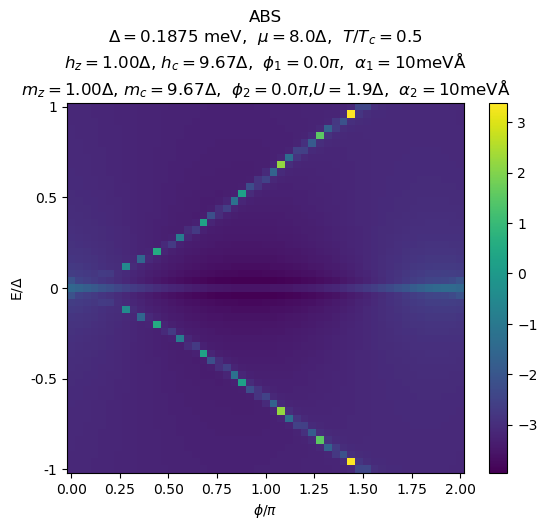

In [58]:
#ABS
num_ef = 50
efmin = -Delta
efmax = Delta
def_ = (efmax - efmin) / num_ef
num_phi = 50
phi_min = 0
phi_max = 2 * np.pi
dphi = (phi_max - phi_min) / num_phi

# Initialize grids
ef_plot = np.zeros(num_ef + 1)
phi_plot = np.zeros(num_phi + 1)
ABS = np.zeros((num_ef + 1, num_phi + 1))

for jj in range(num_ef + 1):
    ef = efmin + def_ * jj
    ef_plot[jj] = ef
    for ii in range(num_phi + 1):
        phi = phi_min + dphi * ii
        phi_plot[ii] = phi / np.pi
        
        # Update Delta and H_l, H_r based on phi
        Delta_L = Delta * np.exp(-1j * phi / 2) * 1j * sy
        H_L_onsite = np.block([
            [HL_block, Delta_L],
            [Delta_L.conj().T, -HL_block.conj()]
        ])
        Delta_R = Delta * np.exp(+1j * phi / 2) * 1j * sy
        H_R_onsite = np.block([
            [HR_block, Delta_R],
            [Delta_R.conj().T, -HR_block.conj()]
        ])
        H_l = H_L_onsite
        H_r = H_R_onsite
        
        # Compute G_DD_r
        G_DD_r, _, _, _ = Gr_DD(
            H_q, H_l, H_r,
            T_12, T_LD, T_l, T_RD, T_r,
            N, ef
        )
        
        # Compute ABS (bufeng)
        ABS[jj, ii] = bufeng(G_DD_r)

# Figure
plt.figure()
X, Y = np.meshgrid(phi_plot, ef_plot)
plt.pcolormesh(X, Y, np.log(ABS + 1e-10), shading='auto')  # Added small epsilon to avoid log(0)
plt.colorbar(location='right')
plt.xlabel(r'$\phi$/$\pi$')

plt.ylabel('E/$\Delta$')
plt.yticks(
    [-Delta, -Delta/2, 0, Delta/2, Delta],
    [-1, -0.5, 0, 0.5, 1]
)
plt.title(
    f'ABS\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.axis('square')
plt.axis('tight')
plt.show()

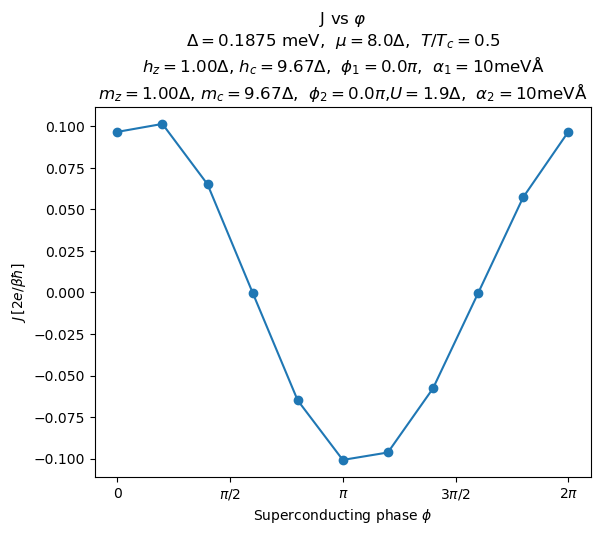

In [63]:
phi_list = np.linspace(0, 2*np.pi, 11)
J_list = []

for phi in phi_list:
    chaodaojiao = phi

    Delta_L = Delta * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    Jphi = JoseCurrent(H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD)

    J_list.append(Jphi)

plt.figure()
plt.plot(phi_list, J_list, marker='o')
plt.xlabel(r'Superconducting phase $\phi$')
plt.ylabel(r'$J\,[2e/\beta\hbar]$')
plt.xticks(
    [0, np.pi/2, np.pi, 3*np.pi/2, 2*np.pi],
    ['0', r'$\pi/2$', r'$\pi$', r'$3\pi/2$', r'$2\pi$']
)
plt.title(
    f'J vs $\\varphi$\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.show()



In [52]:
def J_of_phi(phi):

    Delta_L = Delta * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
    Jphi = JoseCurrent(H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD)
    return Jphi
def J_of_phi_c(phi):

    Delta_L = Delta * np.exp(-1j*phi/2) * 1j * sy
    H_l = np.block([
        [ HL_block,         Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    Delta_R = Delta * np.exp(+1j*phi/2) * 1j * sy
    H_r = np.block([
        [ HR_block,         Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    Jphi = JoseCurrent(H_l,H_r,H_q,T_l,T_r,T_12,T_RD,T_LD)
    #print(f"phi = {float(phi):.3f}, J = {Jphi:.3f}")
    return Jphi
def find_J_extreme_fmin(phi_min=0.9*np.pi, phi_max=1.1*np.pi,
                       N_guess=1, xtol=1e-6, ftol=1e-6,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        max_list.append(rmax[0])

        # 最小值
        rmin = fmin(lambda phi: J_of_phi(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)
        min_list.append(rmin[0])

    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    J_max = max(J_of_phi(phi) for phi in phi_max_list)
    J_min = min(J_of_phi(phi) for phi in phi_min_list)

    yinzi = (abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, J_min, yinzi
def find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-6, ftol=1e-6,
                       round_digits=6):

    phi_guesses = np.linspace(phi_min, phi_max, N_guess)

    max_list = []
    min_list = []

    for phi0 in phi_guesses:

        # 最大值
        rmax = fmin(lambda phi: -J_of_phi_c(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)

        phi_max_found = rmax[0]
        Jmax_found = J_of_phi_c(phi_max_found)

        #print(f"找到一个最大值: phi = {phi_max_found:.6f} π,  J = {Jmax_found:.6e}")

        max_list.append(phi_max_found)


        # 最小值
        rmin = fmin(lambda phi: J_of_phi_c(phi), phi0,
                    disp=False, xtol=xtol, ftol=ftol)

        phi_min_found = rmin[0]
        Jmin_found = J_of_phi_c(phi_min_found)

        #print(f"找到一个最小值: phi = {phi_min_found:.6f} π,  J = {Jmin_found:.6e}")

        min_list.append(phi_min_found)


    phi_max_list = np.unique(np.round(max_list, round_digits))
    phi_min_list = np.unique(np.round(min_list, round_digits))

    # 找真正极值
    J_max = -np.inf
    phi_at_Jmax = None

    for phi in phi_max_list:
        val = J_of_phi(phi)
        if val > J_max:
            J_max = val
            phi_at_Jmax = phi

    J_min = np.inf
    phi_at_Jmin = None

    for phi in phi_min_list:
        val = J_of_phi(phi)
        if val < J_min:
            J_min = val
            phi_at_Jmin = phi

    yinzi = (abs(J_max) - abs(J_min)) / (abs(J_max) + abs(J_min))

    return J_max, phi_at_Jmax/np.pi, J_min, phi_at_Jmin/np.pi, yinzi
J_of_phi(0),J_of_phi(np.pi/2),J_of_phi(2*np.pi)

(0.09260830882718822, 0.04503110801544464, 0.09260830882718232)

In [53]:
shumu=int(np.floor(50*Delta / T_Tc))
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
a1=find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)[0]
print('这时Jmax=',a1)
shumu=int(np.floor(50*Delta/ T_Tc))+1
print('n*2*np.pi*KBT/Delta=',shumu*2*np.pi*KBT/Delta)
a2=find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)[0]
print('这时Jmax=',a2)
print('因子差=',abs(abs(a1)-abs(a2))/(abs(a1)+abs(a2)))

shumu=int(np.floor(50*Delta / T_Tc))
a2,a3,a4,a5,a6=find_J_extreme_fmin_ceshi(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)
print(a2,a3,'\n',a4,a5,'\n',a6)


n*2*np.pi*KBT/Delta= 32.458481097839275
这时Jmax= 0.10474575535704844
n*2*np.pi*KBT/Delta= 34.367803515359235
这时Jmax= 0.10474575594691457
因子差= 2.815704199625557e-09
0.10474575535704844 0.1565104245574804 
 -0.10413578202161172 1.1080730011328002 
 0.0029201878877928833


In [64]:
a2,a3,a4,a5,a6=find_J_extreme_fmin_ceshi(phi_min=np.pi*1, phi_max=np.pi*1,
                       N_guess=1, xtol=1e-3, ftol=1e-3,
                       round_digits=6)
print(a2,a3,'\n',a4,a5,'\n',a6)

0.10440672881503502 0.12480453172437157 
 -0.10378308754517418 1.0763671082996915 
 0.002995541668483028


<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\e'
C:\Users\taoji\AppData\Local\Temp\ipykernel_23896\977758292.py:46: SyntaxWarning: invalid escape sequence '\e'
  f'$\eta$ vs $mz$\n'


mz = 0.000, yinzi = -0.000000000000
mz = 0.019, yinzi = 0.000019696693
mz = 0.037, yinzi = 0.000039412864
mz = 0.056, yinzi = 0.000059167745
mz = 0.075, yinzi = 0.000078983215
mz = 0.094, yinzi = 0.000098867459
mz = 0.112, yinzi = 0.000118860532
mz = 0.131, yinzi = 0.000138948817
mz = 0.150, yinzi = 0.000159200751
mz = 0.169, yinzi = 0.000179572399
mz = 0.188, yinzi = 0.000200115266
mz = 0.206, yinzi = 0.000220838210
mz = 0.225, yinzi = 0.000241750439
mz = 0.244, yinzi = 0.000262858799
mz = 0.263, yinzi = 0.000284212064
mz = 0.281, yinzi = 0.000305757295
mz = 0.300, yinzi = 0.000327584057
mz = 0.319, yinzi = 0.000349633959
mz = 0.337, yinzi = 0.000371955637
mz = 0.356, yinzi = 0.000394504679
mz = 0.375, yinzi = 0.000417348943


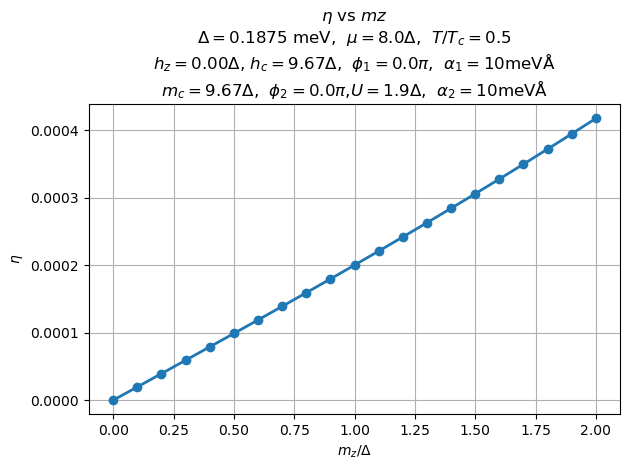

In [33]:
#mz bian
mz_list = np.linspace(0*dela, 2*dela, 21)
yinzi_list = np.zeros(len(mz_list))

for i, mz_val in enumerate(mz_list):
    hz=0
    mz = mz_val

    H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
    H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    H_q = H_center
    

    HL_block = -(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy + hz*sz
    HR_block = -(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy  + hz*sz

    H_l = np.block([
        [ HL_block, Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    H_r = np.block([
        [ HR_block, Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])
    J_max, J_min, yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

    yinzi_list[i] = yinzi

    print(f"mz = {mz_val:.3f}, yinzi = {yinzi:.12f}")



plt.figure()

plt.plot(mz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$m_z$/$\Delta$')
plt.ylabel(r'$\eta$')
plt.title(
    f'$\eta$ vs $mz$\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f'$h_z = {hz/dela:.2f}\\Delta$, $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.grid(True)
plt.tight_layout()
plt.show()

<>:48: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\e'
C:\Users\taoji\AppData\Local\Temp\ipykernel_2076\3353319865.py:48: SyntaxWarning: invalid escape sequence '\e'
  f'$\eta$ vs $hz$\n'


hz = 0.0, yinzi = -8.297837315121281e-14
hz = 1.875, yinzi = 0.00022800662359293285
hz = 3.75, yinzi = 2.2255739446690673e-05
hz = 5.625, yinzi = 3.5499390456894265e-06
hz = 7.5, yinzi = 3.581476393322356e-07
hz = 9.375, yinzi = -2.6865397317238897e-07
hz = 11.25, yinzi = -3.553474019553315e-07
hz = 13.125, yinzi = -3.022873214631616e-07
hz = 15.0, yinzi = -2.289446310426955e-07
hz = 16.875, yinzi = -1.5523255100997898e-07
hz = 18.75, yinzi = -8.779407573573437e-08


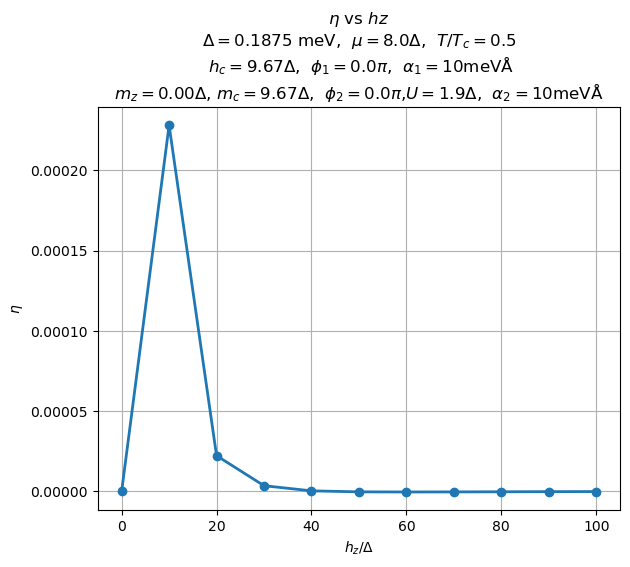

In [30]:
#hz bian
mz = 0
hz_list = np.linspace(0*dela, 100*dela, 11)
yinzi_list = np.zeros(len(hz_list))

for i, hz_val in enumerate(hz_list):

    hz = hz_val

    H_center_block=(U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy
    H_center=np.block([
        [ H_center_block,        np.zeros((2,2)) ],
        [ np.zeros((2,2)) , -H_center_block.conj()  ]
    ])
    H_q = H_center
    
    HL_block = -(mu-2*t)*s0 + h*np.cos(0)*sx + h*np.sin(0)*sy + hz*sz
    HR_block = -(mu-2*t)*s0 + h*np.cos(saimanjiao)*sx + h*np.sin(saimanjiao)*sy  + hz*sz

    H_l = np.block([
        [ HL_block, Delta_L ],
        [ Delta_L.conj().T, -HL_block.conj() ]
    ])

    H_r = np.block([
        [ HR_block, Delta_R ],
        [ Delta_R.conj().T, -HR_block.conj() ]
    ])

    J_max, J_min, yinzi = find_J_extreme_fmin(phi_min=0, phi_max=2*np.pi,
                       N_guess=4, xtol=1e-3, ftol=1e-3,
                       round_digits=6)

    yinzi_list[i] = yinzi

    print(f"hz = {hz_val}, yinzi = {yinzi}")
    
plt.figure()

plt.plot(hz_list/dela, yinzi_list, 'o-', linewidth=2)

plt.xlabel(r'$h_z$/$\Delta$')
plt.ylabel(r'$\eta$')

plt.grid(True)
plt.tight_layout()
plt.title(
    f'$\eta$ vs $hz$\n'
    f'$\\Delta = {dela:.4f}$ meV,  $\\mu = {mu/dela:.1f}\\Delta$,  $T/T_c = {T_Tc}$\n'
    f' $h_c = {h/dela:.2f}\\Delta$,  $\\phi_1 = {saimanjiao / np.pi:.1f}\\pi$,  $\\alpha_1 = {af*10}$meVÅ\n'
    f'$m_z = {mz/dela:.2f}\\Delta$, $m_c = {m/dela:.2f}\\Delta$,  $\\phi_2 = {zhongjian_saimanjiao / np.pi:.1f}\\pi$,$U = {U/dela:.1f}\\Delta$,  $\\alpha_2 = {af*af6666*10}$meVÅ'
)
plt.show()

In [ ]:
#找mz,变的因子最值
def abs_yinzi_of_mz(mz_val):
    global mz, H_q

    if mz_val < 0 or mz_val > 3*Delta:
        raise ValueError("mz out of range")

    # 如果mz_val是数组（从fmin传入），转为标量
    if isinstance(mz_val, np.ndarray):
        mz_val = mz_val.item()  # 或 mz_val[0] 如果是(1,)数组

    mz = mz_val

    H_center_block = (U-mu+2*t)*s0 + mz*sz + m*np.cos(zhongjian_saimanjiao)*sx + m*np.sin(zhongjian_saimanjiao)*sy

    H_q = np.block([
        [ H_center_block, np.zeros((2,2)) ],
        [ np.zeros((2,2)), -H_center_block.conj() ]
    ])

    J_max, phi_max, J_min, phi_min, yinzi = find_J_extreme_fmin_ceshi(
        phi_min=0,
        phi_max=2*np.pi,
        N_guess=4,
        xtol=1e-3,
        ftol=1e-3
    )

    # 确保yinzi是标量
    if isinstance(yinzi, np.ndarray):
        yinzi = yinzi.item()  # 转为float

    val = abs(yinzi)

    # print时直接转为float
    print(f"mz = {mz_val:.6f}  |yinzi| = {float(val):.6f}")

    return val
def find_yinzi_extreme_mz(mz_min=0*Delta, mz_max=2*Delta,
                         N_guess=3, xtol=1e-6, ftol=1e-6,
                         round_digits=6):

    mz_guesses = np.linspace(mz_min, mz_max, N_guess)

    max_list = []
    min_list = []

    global_best_max = -np.inf
    global_best_max_mz = None

    global_best_min = np.inf
    global_best_min_mz = None

    for mz0 in mz_guesses:

        print("\n===== Starting guess mz =", mz0, "=====")

        # ---------- 找最大 ----------
        try:

            rmax = fmin(lambda mz: -abs_yinzi_of_mz(mz),
                        mz0,
                        disp=False,
                        xtol=xtol,
                        ftol=ftol)

            max_list.append(rmax[0])

        except ValueError:

            print("Stop search (mz out of range)")

        # ---------- 找最小 ----------
        try:

            rmin = fmin(lambda mz: abs_yinzi_of_mz(mz),
                        mz0,
                        disp=False,
                        xtol=xtol,
                        ftol=ftol)

            min_list.append(rmin[0])

        except ValueError:

            print("Stop search (mz out of range)")


    mz_max_list = np.unique(np.round(max_list, round_digits))
    mz_min_list = np.unique(np.round(min_list, round_digits))

    # ----------- 计算真正最大 ----------
    for mz_val in mz_max_list:

        val = abs_yinzi_of_mz(mz_val)

        if val > global_best_max:

            global_best_max = val
            global_best_max_mz = mz_val

            print("\n>>> NEW GLOBAL MAX")
            print("mz =", mz_val)
            print("|yinzi| =", val)


    # ----------- 计算真正最小 ----------
    for mz_val in mz_min_list:

        val = abs_yinzi_of_mz(mz_val)

        if val < global_best_min:

            global_best_min = val
            global_best_min_mz = mz_val

            print("\n>>> NEW GLOBAL MIN")
            print("mz =", mz_val)
            print("|yinzi| =", val)


    return global_best_max, global_best_max_mz, global_best_min, global_best_min_mz
yinzi_max, mz_max, yinzi_min, mz_min = find_yinzi_extreme_mz()

print("\n====== FINAL RESULT ======")
print("max |yinzi| =", yinzi_max, " at mz =", mz_max)
print("min |yinzi| =", yinzi_min, " at mz =", mz_min)